### This notebook compute "P10. Volume of the glacial lagoon" indicator for the 27 basins of IKI Project

Spanish: Volumen de la laguna glaciar

**Created:** 6/23/2025 by Jorge Mayo/ Serena Gilson current contact: Sophia Bakar (sbakar@rti.org) 

**Inputs:**   MAPA_NACIONAL_DE_ECOSISTEMAS_2012-2018 (MINAM), INAIGEM inventario de glaciares 2020 https://geocatmin.ingemmet.gob.pe/geocatmin/
 
**Assumptions:** Used COMID to associate lagoons that are "below" a glacier. 

Could not find lagoon depth so assumed average depth of .03 for all. Used km for ranges and seemed to have an appropriate distribution. 
 
**N/A Handling:** COMIDs without lagoons are NaN in level assignments.

**Notes:**  Will need to update this script if we get future shapefiles for glaciers

General methodology:  
1. Spatial join COMIDs and lagoon datasets.  
2. Calculate the area of each lagoon (km2). Convert to volume using an assumed depth of 0.03 km. 
3. Calculate total lagoon volume per COMID.  
4. Filter for COMIDs with glaciers to determine which lagoons are glacial lagoons.  
5. Assign a lagoon volume score: NaN for 0 km,  1 for volumes > 50 km3, 0.75 for volumes (20, 50] km3; 0.50 for volumes (10, 20] km3; 0.25 for volums < 10 km3.  

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import rasterio
import yaml
from pathlib import Path

In [2]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [3]:
# set paths for input data and indicators database 
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"
glaciares_actual = master_path / "Indicadores" / "Datos_INAIGEM" / "Glaciares_2020_COMID_v2.shp"
mapa_ecosistemas = master_path / "Indicadores" / "Datos_MINAM" / "MAPA_NACIONAL_DE_ECOSISTEMAS_20-12-2018.shp"
glaciares_futuro = master_path / "Indicadores" / "Datos_INAIGEM" / "glaciares_2050_SSP585.shp"

In [4]:
# set up indicator ID and get scenarios from database
IndID= 110 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

scenario_ids = scenarios_df['ScnID'].tolist()


In [5]:
# update if scenario IDs change
scenario_glacier_config = {
    1: {
        "use_future_glaciers": False
    },
    2: {
        "use_future_glaciers": True
    },
    3: {
        "use_future_glaciers": True
    }
}


In [6]:
#read ecosystems shapefile
mapa_ecosistemas_gdf= gpd.read_file(mapa_ecosistemas)

#Filter mapa_ecosistemas_gdf for ECO_LAYER= "Lagos and Lagunas"
mapa_lag_gdf = mapa_ecosistemas_gdf[mapa_ecosistemas_gdf['ECO_LAYER'] == 'Lago y laguna']

# read in the subbasins and glaciers shapefiles
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
glaciares_actual_gdf = gpd.read_file(glaciares_actual).to_crs('EPSG:32718')
glaciares_futuro_gdf = gpd.read_file(glaciares_futuro).to_crs("EPSG:32718")

In [7]:
# --------------------------------------------------
# Calculate lagoon volume by COMID
# --------------------------------------------------

subbasins_with_lagoon = gpd.sjoin(
    subbasins_gdf,
    mapa_lag_gdf,
    how="inner",
    predicate="intersects"
)

subbasins_with_lagoon["Lagoon_Area_Km2"] = (
    subbasins_with_lagoon.geometry.area / 1_000_000
)

average_depth_km = 0.03

subbasins_with_lagoon["Lagoon_Volume_Km3"] = (
    subbasins_with_lagoon["Lagoon_Area_Km2"] * average_depth_km
)

lagoon_volume_by_comid = (
    subbasins_with_lagoon
    .groupby("COMID")["Lagoon_Volume_Km3"]
    .sum()
    .reset_index()
)


In [8]:
def assign_lagoon_score(volume_km3):
    if pd.isna(volume_km3) or volume_km3 == 0:
        return np.nan
    elif volume_km3 > 50:
        return 1
    elif 20 <= volume_km3 <= 50:
        return 0.75
    elif 10 <= volume_km3 < 20:
        return 0.50
    else:
        return 0.25

In [9]:
# --------------------------------------------------
# Build baseline lagoon scores using current glacier inventory
# --------------------------------------------------

baseline_glacier_comids = (
    glaciares_actual_gdf["COMID"]
    .dropna()
    .unique()
)

baseline_lagoon_volume = lagoon_volume_by_comid[
    lagoon_volume_by_comid["COMID"].isin(baseline_glacier_comids)
].copy()

baseline_subbasins = subbasins_gdf.merge(
    baseline_lagoon_volume,
    on="COMID",
    how="left"
)

baseline_subbasins["Lagoon_Volume_Km3"] = (
    baseline_subbasins["Lagoon_Volume_Km3"]
    .fillna(0)
    .round(4)
)

baseline_subbasins["Lagoon_Volume_Score"] = (
    baseline_subbasins["Lagoon_Volume_Km3"]
    .apply(assign_lagoon_score)
)

baseline_subbasins = baseline_subbasins.rename(
    columns={
        "Lagoon_Volume_Km3": "Baseline_Lagoon_Volume_Km3",
        "Lagoon_Volume_Score": "Baseline_Lagoon_Volume_Score"
    }
)


In [10]:
# --------------------------------------------------
# Build future lagoon scores using projected glacier inventory
# --------------------------------------------------

future_glacier_comids = (
    glaciares_futuro_gdf["COMID"]
    .dropna()
    .unique()
)

future_lagoon_volume = lagoon_volume_by_comid[
    lagoon_volume_by_comid["COMID"].isin(future_glacier_comids)
].copy()

future_subbasins = subbasins_gdf.merge(
    future_lagoon_volume,
    on="COMID",
    how="left"
)

future_subbasins["Lagoon_Volume_Km3"] = (
    future_subbasins["Lagoon_Volume_Km3"]
    .fillna(0)
    .round(4)
)

future_subbasins["Lagoon_Volume_Score"] = (
    future_subbasins["Lagoon_Volume_Km3"]
    .apply(assign_lagoon_score)
)

future_subbasins = future_subbasins.rename(
    columns={
        "Lagoon_Volume_Km3": "Future_Lagoon_Volume_Km3",
        "Lagoon_Volume_Score": "Future_Lagoon_Volume_Score"
    }
)


In [11]:
# --------------------------------------------------
# Combine baseline and future scores
# --------------------------------------------------

combined_scores = baseline_subbasins.merge(
    future_subbasins[
        [
            "COMID",
            "Future_Lagoon_Volume_Km3",
            "Future_Lagoon_Volume_Score"
        ]
    ],
    on="COMID",
    how="left"
)

future_projection_comids = set(
    glaciares_futuro_gdf["COMID"]
    .dropna()
    .unique()
)

combined_scores["Has_Future_Projection"] = (
    combined_scores["COMID"].isin(future_projection_comids)
)

print("Baseline score distribution:")
print(
    combined_scores["Baseline_Lagoon_Volume_Score"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nFuture score distribution:")
print(
    combined_scores["Future_Lagoon_Volume_Score"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nCOMIDs with future glacier projection:")
print(combined_scores["Has_Future_Projection"].sum())

Baseline score distribution:
Baseline_Lagoon_Volume_Score
0.25      99
0.50      33
0.75      33
1.00      16
NaN     3474
Name: count, dtype: int64

Future score distribution:
Future_Lagoon_Volume_Score
0.25      18
0.50       4
0.75       7
1.00       2
NaN     3624
Name: count, dtype: int64

COMIDs with future glacier projection:
52


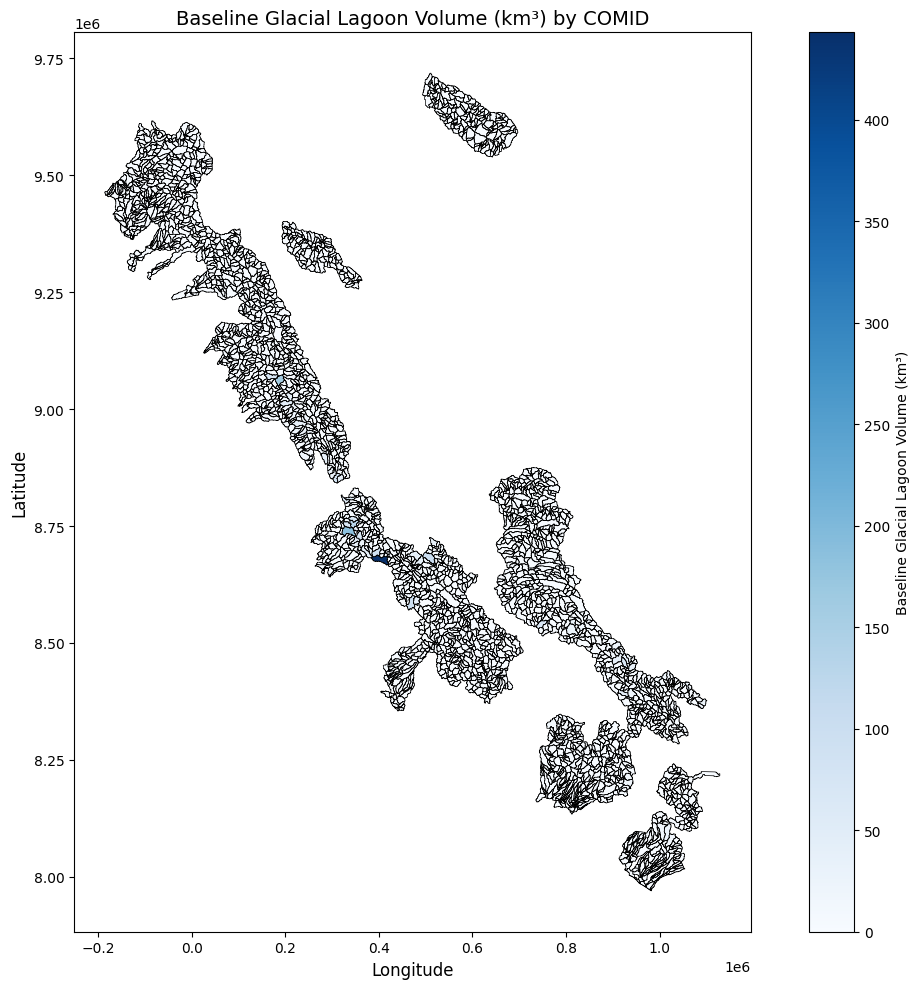

In [12]:
# --------------------------------------------------
# Optional plot
# --------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

combined_scores.plot(
    column="Baseline_Lagoon_Volume_Km3",
    ax=ax,
    legend=True,
    cmap="Blues",
    edgecolor="black",
    linewidth=0.5,
    legend_kwds={"label": "Baseline Glacial Lagoon Volume (km³)"}
)

ax.set_title("Baseline Glacial Lagoon Volume (km³) by COMID", fontsize=14)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

plt.tight_layout()
plt.show()


In [13]:
# --------------------------------------------------
# Prepare rows by scenario
# --------------------------------------------------

conn = sqlite3.connect(db_path)
cursor = conn.cursor()

rows_to_insert = []

for scn_id in scenario_ids:

    cfg = scenario_glacier_config.get(
        scn_id,
        {"use_future_glaciers": False}
    )

    scenario_df = combined_scores.copy()

    scenario_df["Value"] = scenario_df["Baseline_Lagoon_Volume_Score"]

    if cfg["use_future_glaciers"]:

        mask_future_projected = scenario_df["Has_Future_Projection"]

        scenario_df.loc[
            mask_future_projected,
            "Value"
        ] = scenario_df.loc[
            mask_future_projected,
            "Future_Lagoon_Volume_Score"
        ]

    for _, row in scenario_df.iterrows():

        rows_to_insert.append((
            scn_id,
            IndID,
            int(row["COMID"]),
            None if pd.isna(row["Value"]) else float(row["Value"])
        ))



In [14]:
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [15]:
# --------------------------------------------------
# Check indicator limits and scenario stats
# --------------------------------------------------

indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, "Min"]
ind_max = indicator_limits.loc[0, "Max"]

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

df_check = pd.DataFrame(
    rows_to_insert,
    columns=["ScnID", "IndID", "COMID", "Value"]
)

value_stats_by_scenario = (
    df_check
    .groupby("ScnID")["Value"]
    .agg(["min", "max", "count"])
    .reset_index()
    .merge(scenarios_df, on="ScnID", how="left")
)

value_stats_by_scenario["Indicator_Min"] = ind_min
value_stats_by_scenario["Indicator_Max"] = ind_max

print("\n=== Values to be inserted by scenario ===")
print(
    value_stats_by_scenario[
        [
            "ScnID",
            "ScnName",
            "min",
            "max",
            "count",
            "Indicator_Min",
            "Indicator_Max"
        ]
    ]
)

duplicates = df_check.duplicated(
    subset=["ScnID", "IndID", "COMID"]
)

print("\nDuplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 110  Min: 0.25, Max: 1

=== Values to be inserted by scenario ===
   ScnID      ScnName   min  max  count  Indicator_Min  Indicator_Max
0      1   Linea Base  0.25  1.0    181           0.25              1
1      2  CC CMIP6 85  0.25  1.0    181           0.25              1
2      3  CC CMIP6 45  0.25  1.0    181           0.25              1

Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [16]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()